# Robust Deep Learning Projections Reveal Intensification and Seasonal Reorganization of Fire Weather over the Iberian Peninsula


**Based on:** Mirones et al. (2026) - "Robust Deep Learning Projections Reveal Intensification and Seasonal Reorganization of Fire Weather over the Iberian Peninsula"

**Author:** Óscar Mirones  
**Date:** 2026  
**Framework:** R with Keras/TensorFlow (climate4R, downscaleR.keras)  
**Data Sources:** ERA5-Land Reanalysis (0.1°), ERA5 Reanalysis (0.25º) & Interpolated CMIP6 Global Climate Models (1.5°)  
**Region:** Iberian Peninsula  
**Output Resolution:** 0.1° (~11 km)

---

## Table of Contents

1. [**Study Overview**](#overview-anchor)
2. [**Environment Setup**](#setup-anchor)
3. [**Phase 1: Training Data Preparation**](#phase1-anchor)
4. [**Phase 2: Deep Learning Model Development**](#phase2-anchor)
5. [**Phase 3: Climate Projections Processing**](#phase3-anchor)
6. [**Phase 4: Downscaling & Results**](#phase4-anchor)

---

<a id='overview-anchor'></a>

*This notebook is a simple adaptation of the study carried on Mirones et al.(2026)*.

## Study Overview

### Scientific Context
The Iberian Peninsula exhibits heightened vulnerability to fire weather due to increasing heatwaves, persistent droughts, and land-use changes. Understanding how fire weather patterns will intensify and reorganize seasonally under future climate change is critical for fire management and climate adaptation. 

### Objective
Downscale high-resolution (0.1°) projections of the Fire Weather Index (FWI) over the Iberian Peninsula using deep learning (DL) to:
- Downscale coarse daily mean (DM) climate data (1.5°) to instantaneous regional scales.
- Overcome limitations of General Circulation Models that lack 12 UTC instantaneous variables required for physically consistent FWI calculations.
- Project changes in fire-weather intensity and seasonal timing under multiple emissions scenarios.

### Methodology
**Model Architecture:** U-Net Convolutional Neural Network.
- **Training Data** (1979-2014)
    - **Predictors:** DM temperature, relative humidity, and wind speed from ERA5 interpolated to a coarse 1.5° resolution.
    - **Predictand (Target):** Fire Weather Index at 12 UTC (0.1° resolution) from ERA5-Land.
- **Future Projections:** EC-EARTH3 (1.5º) across SSP5-8.5 scenario during the end of the century (2080-2099).

### Key Features
- **Change-Preserving Bias Adjustment:** Scaling Delta Mapping (SDM) ensures large-scale climate change signals are preserved.
- **Physically Consistent:** Reconstructs 12 UTC FWI instead of relying on daily-mean approximations.
- **Transferable:** Generalizes across EC-EARTH3 model under a warmer scenario than the used in the DL model training.
- **Robust:** Provides added value for both mean fire-weather conditions and extreme events (FWI95).

---

<a id='setup-anchor'></a>

## Environment Setup


In [1]:
options(java.parameters = "-Xmx64g")

library(magrittr)
library(loadeR)
library(yaml)
library(transformeR)
library(keras)
library(tensorflow)
library(downscaleR.keras)
library(visualizeR)
library(RColorBrewer)

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

NetCDF Java Library v4.6.0-SNAPSHOT (23 Apr 2015) loaded and ready

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.1 (2023-06-22) is loaded


Get the latest stable version (1.8.2) using <devtools::install_github(c('SantanderMetGroup/climate4R.UDG','SantanderMetGroup/loadeR'))>

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

Loading required package: downscaleR

downscaleR version 3.3.4 (2023-06-22) is loaded

Please use 'citation("downscaleR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.



In [ ]:
tensorflow::install_tensorflow() #run just the first time to install tensorflow

### Load Configuration

This .yaml file contains the configuration which defines the main optimization settings for training the deep learning model:

- **Batch size (`64`)**: Number of samples processed before updating model weights. A moderate batch size balances training stability and computational efficiency.
- **Epochs (`1000`)**: Maximum number of full passes through the training dataset.
- **Patience (`15`)**: Early stopping criterion; training stops if validation performance does not improve for 15 consecutive epochs.
- **Learning rate (`0.0001`)**: Controls the step size of weight updates during optimization. A small value ensures stable and gradual learning.

Together, these parameters allow long training while preventing unnecessary computation through early stopping and maintaining controlled optimization updates.

In [2]:
#read .yaml file
config <- yaml.load_file("dl_config.yaml")

---
<a id='phase1-anchor'></a>

## Phase 1: Training Data Preparation

This phase loads and preprocesses the historical training dataset (ERA5-Land, 1979-2014). The U-Net model learns the nonlinear mapping between coarse-resolution predictor variables (DM temperature, humidity, wind) and high-resolution FWI estimates at 12 UTC.

### Fire Weather Index (FWI) Training Data

The Fire Weather Index is a widely-adopted global standard that integrates near-surface temperature, relative humidity, wind speed, and precipitation. This notebook loads ERA5-Land FWI data computed at 12 UTC for the historical period (1979-2014) at 0.1° resolution, which serves as the training target for the deep learning model.

**FWI Components:**
- Uses daily mean (DM) meteorological variables from ERA5.
- Instantaneous variables at 12:00 UTC to align with local noon over Iberia.
- Six intermediate components characterizing fuel moisture dynamics across different fuel layers.
- Final index represents potential fire intensity under given meteorological conditions for mature pine stands.

Below is the FWI System structure:

<p align="center">
  <img src="aux/fwi_structure.png" width="600">
</p>

In [3]:
#load the fwi12 as predictand, named as y
yTrain <- loadGridData("data/ERA5/yTrain.nc",
                       var = "FWI")

[2026-04-28 17:50:49.938214] Defining geo-location parameters

[2026-04-28 17:50:49.994341] Defining time selection parameters

[2026-04-28 17:50:50.171827] Retrieving data subset ...

[2026-04-28 17:51:35.402776] Done



In [4]:
fwi.colors <- colorRampPalette(c(rev(brewer.pal(9, "YlGnBu")[3:5]), 
                                 brewer.pal(9, "YlOrRd")[3:9]))

[2026-04-28 17:51:36.336957] - Computing climatology...

[2026-04-28 17:51:38.978112] - Done.



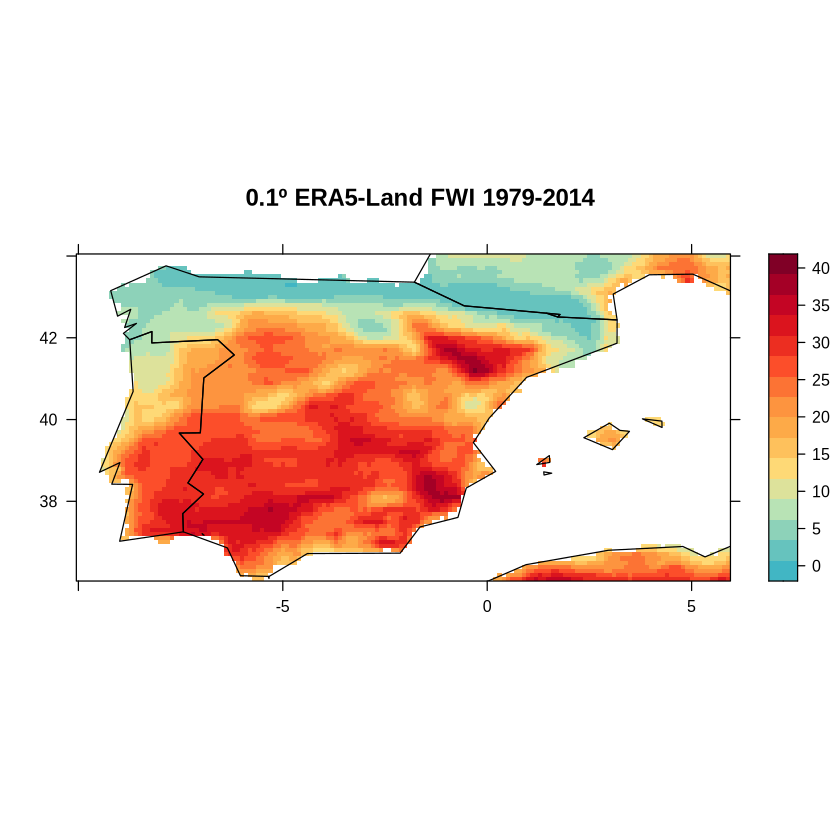

In [5]:
spatialPlot(climatology(yTrain), backdrop.theme = 'countries', col.regions = fwi.colors,
           main = "0.1º ERA5-Land FWI 1979-2014", scales = list(draw = TRUE))

### Data Download

The data required to fully reproduce the code must be downloaded from 10.5281/zenodo.19912048 and placed in the appropriate directory structure. The following code automatically downloads and organizes the data according to the required folder structure.


In [20]:
#urls links for the data
ec.earth_urls <- c("https://zenodo.org/records/19912049/files/hurs_EC-EARTH_historical.nc?download=1",
              "https://zenodo.org/records/19912049/files/hurs_EC-EARTH_ssp585.nc?download=1",
              "https://zenodo.org/records/19912049/files/sfcwind_EC-EARTH_historical.nc?download=1",
              "https://zenodo.org/records/19912049/files/sfcwind_EC-EARTH_ssp585.nc?download=1",
              "https://zenodo.org/records/19912049/files/t2m_EC-EARTH_historical.nc?download=1",
              "https://zenodo.org/records/19912049/files/t2m_EC-EARTH_ssp585.nc?download=1")

era5_urls <- c("https://zenodo.org/records/19912049/files/hurs_ERA5.nc?download=1",
              "https://zenodo.org/records/19912049/files/mask_ERA5Land.nc?download=1",
              "https://zenodo.org/records/19912049/files/sfcwind_ERA5.nc?download=1",
              "https://zenodo.org/records/19912049/files/t2m_ERA5.nc?download=1",
              "https://zenodo.org/records/19912049/files/yTrain.nc?download=1")

model_urls <- "https://zenodo.org/records/19912049/files/unet_surface_huber_deg_1.5.h5?download=1"

In [21]:
# Check whether the required directories exist; create them if they do not
if (!dir.exists("data/ERA5")) {
  dir.create("data/ERA5", recursive = TRUE)
  message("Directory 'data/ERA5' created.")
} else {
  message("Directory 'data/ERA5' already exists.")
}

if (!dir.exists("data/EC-EARTH")) {
  dir.create("data/EC-EARTH", recursive = TRUE)
  message("Directory 'data/EC-EARTH' created.")
} else {
  message("Directory 'data/EC-EARTH' already exists.")
}

if (!dir.exists("models")) {
  dir.create("models", recursive = TRUE)
  message("Directory 'models' created.")
} else {
  message("Directory 'models' already exists.")
}

Directory 'data/ERA5' created.

Directory 'data/EC-EARTH' created.

Directory 'models' created.



<div style="border: 2px solid #f39c12; border-radius: 10px; padding: 15px; background-color: #fff8e6;">

<h3 style="color: #d35400; margin-top: 0;">⚠️ Downloading the data could take some minutes. Be patient :) </h3>

</div>

In [16]:
options(timeout = 300)  # Set timeout to avoid download failure due to slowness

# Download all files
for (file_url in ec.earth_urls) {
  file_name <- sub("\\?.*$", "", basename(file_url))  
  full_file_name <- file.path("data/EC-EARTH", file_name)
  
  download.file(file_url, full_file_name, mode = "wb")
  message("Downloaded: ", file_name)
}

Downloaded: hurs_EC-EARTH_historical.nc

Downloaded: hurs_EC-EARTH_ssp585.nc

Downloaded: sfcwind_EC-EARTH_historical.nc

Downloaded: sfcwind_EC-EARTH_ssp585.nc

Downloaded: t2m_EC-EARTH_historical.nc

Downloaded: t2m_EC-EARTH_ssp585.nc



In [23]:
options(timeout = 300)  # Set timeout to avoid download failure due to slowness

# Download all files
for (file_url in era5_urls) {
  file_name <- sub("\\?.*$", "", basename(file_url))  
  full_file_name <- file.path("data/ERA5", file_name)
  
  download.file(file_url, full_file_name, mode = "wb")
  message("Downloaded: ", file_name)
}

Downloaded: hurs_ERA5.nc

Downloaded: mask_ERA5Land.nc

Downloaded: sfcwind_ERA5.nc

Downloaded: t2m_ERA5.nc

Downloaded: yTrain.nc



In [22]:
options(timeout = 300)  # Set timeout to avoid download failure due to slowness

# Download all files
for (file_url in model_urls) {
  file_name <- sub("\\?.*$", "", basename(file_url))  
  full_file_name <- file.path("models", file_name)
  
  download.file(file_url, full_file_name, mode = "wb")
  message("Downloaded: ", file_name)
}

Downloaded: unet_surface_huber_deg_1.5.h5



### Predictor Variables for the Training

This section loads the predictor variables from coarse-resolution interpolated ERA5 (1.5° grid). The predictors consist of the same variables used in FWI computation without the precipitation. 

**Predictor Set:**
- **2-meter air temperature** (DM)
- **2-meter relative humidity** (DM)
- **10-meter wind speed** (DM)

**Design Choice:** Precipitation is deliberately omitted from the predictor set because its high variability and complex processes introduce noise with limited benefit to FWI estimates. The short-term influence of rainfall is implicitly captured in the memory components of the FWI calculation.


In [6]:
hurs <- loadGridData("data/ERA5/hurs_ERA5.nc",
                       var = "hurs")
t2m <- loadGridData("data/ERA5/t2m_ERA5.nc",
                       var = "t2m")
sfcwind <- loadGridData("data/ERA5/sfcwind_ERA5.nc",
                       var = "sfcwind")

[2026-04-28 17:51:41.551801] Defining geo-location parameters

[2026-04-28 17:51:41.579924] Defining time selection parameters

[2026-04-28 17:51:41.683845] Retrieving data subset ...

[2026-04-28 17:51:43.209731] Done

[2026-04-28 17:51:43.306844] Defining geo-location parameters

[2026-04-28 17:51:43.332708] Defining time selection parameters

[2026-04-28 17:51:43.419584] Retrieving data subset ...

[2026-04-28 17:51:44.790492] Done

[2026-04-28 17:51:44.887726] Defining geo-location parameters

[2026-04-28 17:51:44.913126] Defining time selection parameters

[2026-04-28 17:51:45.005181] Retrieving data subset ...

[2026-04-28 17:51:46.244761] Done



[2026-04-28 17:51:46.263563] - Computing climatology...

[2026-04-28 17:51:46.2746] - Done.



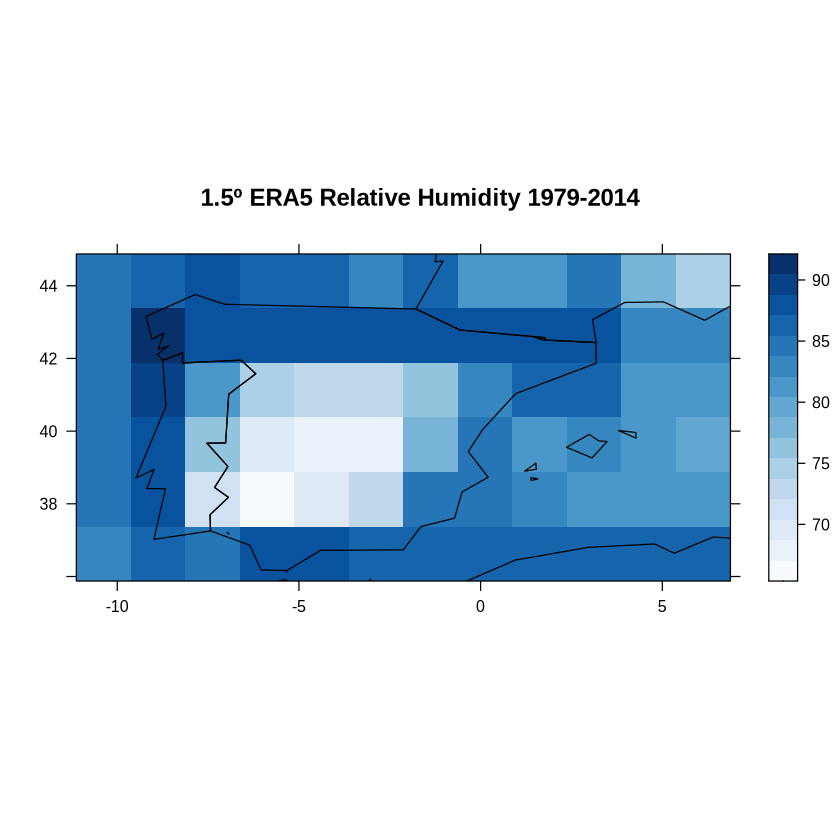

In [7]:
spatialPlot(climatology(hurs), backdrop.theme = 'countries', color.theme = "Blues",
           main = "1.5º ERA5 Relative Humidity 1979-2014", scales = list(draw = TRUE))

[2026-04-28 17:51:48.461133] - Computing climatology...

[2026-04-28 17:51:48.471203] - Done.



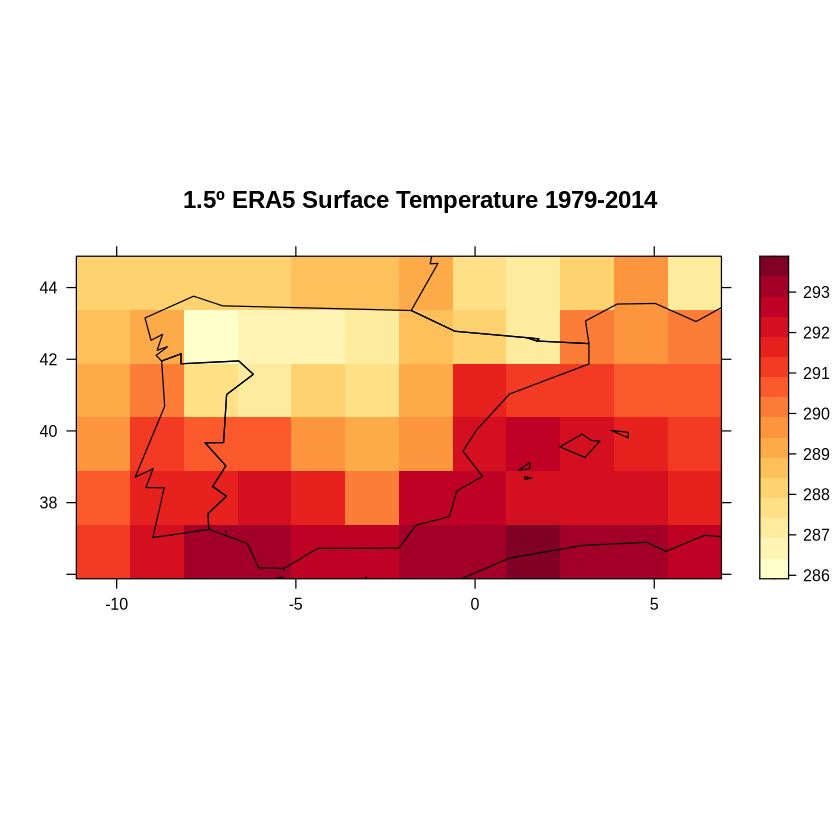

In [8]:
spatialPlot(climatology(t2m), backdrop.theme = 'countries', color.theme = "YlOrRd",
           main = "1.5º ERA5 Surface Temperature 1979-2014", scales = list(draw = TRUE))

[2026-04-28 17:51:50.682506] - Computing climatology...

[2026-04-28 17:51:50.691944] - Done.



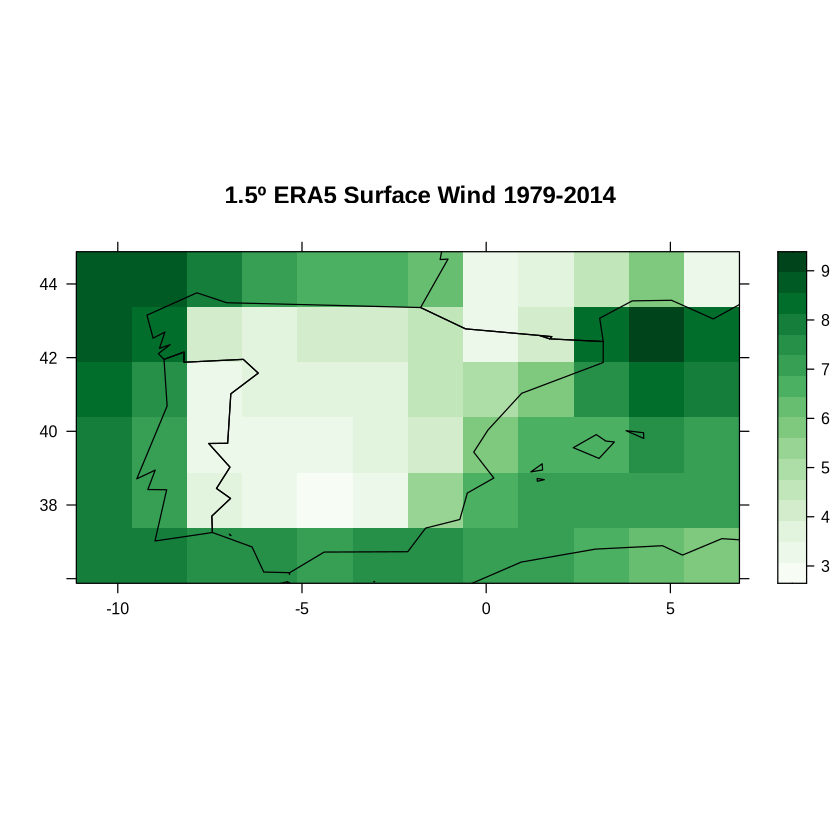

In [9]:
spatialPlot(climatology(sfcwind), backdrop.theme = 'countries', color.theme = "Greens",
           main = "1.5º ERA5 Surface Wind 1979-2014", scales = list(draw = TRUE))

### Data Preprocessing

Data preprocessing applies standardized procedures to ensure consistency and model robustness:

**Interpolation:**
- Aggregate ERA5 native 0.25° fields to 1.5° target resolution using bilinear interpolation *(ERA5 data loaded are already interpolated)*.
- Ensures consistency with GCM predictor space used during downscaling.

**Bias Adjustment (for future projections):**
- Apply Scaling Delta Mapping (SDM) at monthly scale.
- Adjust mean and variance while preserving climate change signal.
- Remove climate change signal before bias adjustment, then add back afterward.

**Standardization:**
- Standardize predictor fields at grid-box level using parameters derived from reanalysis training data.
- Ensures consistent input scaling for EC-EARTH3 model and future periods.


<p align="center">
  <img src="aux/sdm.png" width="600">
</p>

In [10]:
xTrain <- makeMultiGrid(t2m, hurs, sfcwind)

In [11]:
rm(hurs, t2m, sfcwind)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2847381,152.1,6474891,345.8,6474891,345.8
Vcells,176350917,1345.5,589048266,4494.1,736303483,5617.6


In [12]:
# Filter days with NaNs or NA
yTrain <- filterNA(yTrain)

xTrain <- intersectGrid(xTrain, yTrain, which.return = 1)


# Substitute NANs by zero if training CNN_UNET
yTrain$Data[is.na(yTrain$Data)] <- 0

# Standardize predictors
xTrain_stand <- scaleGrid(xTrain, type = 'standardize')

NOTE: Some of the specified dimensions do not exist in the grid

NOTE: Some of the specified dimensions do not exist in the grid

[2026-04-28 17:52:02.376254] - Scaling ...

[2026-04-28 17:52:03.101458] - Done



---
<a id='phase2-anchor'></a>

## Phase 2: Deep Learning Model Development

### U-Net Architecture and Training

A U-Net (modified, since to downscale the U-Net cannot be symmetrical) convolutional neural network is trained to learn the spatial downscaling relationship from 1.5° predictor fields to 0.1° FWI fields.

**Architecture Details:**
- **Encoder:** Four convolutional blocks with ReLU activations and 2×2 max-pooling (64 → 512 channels)
- **Decoder:** Mirror structure with 2×2 transposed convolutions and skip connections
- **Output:** Four additional transposed-convolution layers to attain desired 0.1° resolution + final cropping
- **Loss Function:** Huber loss (robust to outliers, combines quadratic and linear behavior)
- **Optimizer:** Adam with learning rate 0.0001
- **Training:** Batch size 64, maximum 1000 epochs, early stopping if no improvement after 30 consecutive epochs

In [13]:
modelTrain <- function(inp) {
    
    inputs <- layer_input(shape = c(6, 12, getShape(xTrain, "var")))
    padded_inputs <- layer_zero_padding_2d(inputs, padding = list(c(1, 1), c(0, 0)))  # (8, 12)
    
    # Encoder
    l1_conv1 <- layer_conv_2d(padded_inputs, filters = 64, kernel_size = c(3, 3), activation = 'linear', padding = 'same')
    l1_bn <- layer_batch_normalization(l1_conv1)
    l1 <- layer_activation(l1_bn, activation = 'relu')
    l1_mp <- layer_max_pooling_2d(l1, pool_size = c(2, 2))  # 4x6
    
    l2_conv1 <- layer_conv_2d(l1_mp, filters = 128, kernel_size = c(3, 3), activation = 'linear', padding = 'same')
    l2_bn <- layer_batch_normalization(l2_conv1)
    l2 <- layer_activation(l2_bn, activation = 'relu')
    l2_mp <- layer_max_pooling_2d(l2, pool_size = c(2, 2))  # 2x3
    
    l3_conv1 <- layer_conv_2d(l2_mp, filters = 256, kernel_size = c(3, 3), activation = 'linear', padding = 'same')
    l3_bn <- layer_batch_normalization(l3_conv1)
    l3 <- layer_activation(l3_bn, activation = 'relu')
    l3_mp <- layer_max_pooling_2d(l3, pool_size = c(2, 2))  # 1x1
    
    l4_conv1 <- layer_conv_2d(l3_mp, filters = 512, kernel_size = c(3, 3), activation = 'linear', padding = 'same')
    l4_bn <- layer_batch_normalization(l4_conv1)
    l4 <- layer_activation(l4_bn, activation = 'relu')
    
    # Decoder
    d1_up <- layer_conv_2d_transpose(l4, filters = 512, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(2,2)
    d1_up <- layer_zero_padding_2d(d1_up, padding = list(c(0, 0), c(0, 1))) #(2,3)
    d1_concat <- layer_concatenate(list(d1_up, l3), axis = 3)
    d1_conv1 <- layer_conv_2d(d1_concat, filters = 512, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    d1_conv2 <- layer_conv_2d(d1_conv1, filters = 512, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    
    d2_up <- layer_conv_2d_transpose(d1_conv2, filters = 256, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(4,6)
    d2_concat <- layer_concatenate(list(d2_up, l2), axis = 3)
    d2_conv1 <- layer_conv_2d(d2_concat, filters = 256, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    d2_conv2 <- layer_conv_2d(d2_conv1, filters = 256, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    
    d3_up <- layer_conv_2d_transpose(d2_conv2, filters = 128, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(8,12)
    d3_concat <- layer_concatenate(list(d3_up, l1), axis = 3)
    d3_conv1 <- layer_conv_2d(d3_concat, filters = 128, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    d3_conv2 <- layer_conv_2d(d3_conv1, filters = 128, kernel_size = c(3, 3), padding = 'same', activation = 'relu')
    
    
    # Final upsampling and 1x1 conv
    upsampled <- layer_conv_2d_transpose(d3_conv2, filters = 64, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(16,24)
    upsampled2 <- layer_conv_2d_transpose(upsampled, filters = 32, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(32,48)
    upsampled3 <- layer_conv_2d_transpose(upsampled2, filters = 16, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(64,96)
    upsampled4 <- layer_conv_2d_transpose(upsampled3, filters = 8, kernel_size = c(3, 3), strides = c(2, 2), padding = 'same', activation = 'relu') #(128,192)
    
    final_conv <- layer_conv_2d(upsampled4, filters = 1, kernel_size = c(1, 1), activation = 'linear', padding = 'same')
    
    # Crop back to original size: from (128, 192) to (80, 160)
    cropped_output <- layer_cropping_2d(final_conv, cropping = list(c(24, 24), c(16, 16)))
    
    
    model <- keras_model(inputs = inputs, outputs = cropped_output)
    return(model)
}
  
  
xyT <- prepareData.keras(x = xTrain_stand,
                       y = yTrain,
                       first.connection = 'conv',
                       last.connection = 'conv',
                       channels = 'last')

# Train and save the best model
output.file <- "models/model_test.h5"

In [14]:
loss <- function(y_true, y_pred) {
    mask <- k_cast(k_greater(y_true, 0), dtype = k_floatx())
    
    masked_y_true <- y_true * mask
    masked_y_pred <- y_pred * mask
    
    delta <- 1.0 
    
    loss_per_element <- loss_huber(masked_y_true, masked_y_pred, delta = delta)
    num_valid <- k_sum(mask) + k_epsilon()
    
    return(k_sum(loss_per_element) / num_valid)
}

In [15]:
compile.args <- list("loss" = loss,
                     "optimizer" = optimizer_adam(learning_rate = config$params$learning_rate))


fit.args <- list("batch_size" = config$params$batch, 
                 "epochs" = config$params$epochs, 
                 "validation_split" = 0.2, 
                 "verbose" = 1L,
                 "callbacks" = list(callback_early_stopping(patience = config$params$patience), 
                                    callback_model_checkpoint(
                                      filepath = output.file,
                                      monitor = 'val_loss',
                                      save_best_only = TRUE,
                                      save_weights_only = FALSE)))

In [16]:
input <- xyT$x.global

model <- modelTrain(xyT)


model$compile(loss = compile.args[["loss"]],
              optimizer = compile.args[["optimizer"]])

<div style="border: 2px solid #f39c12; border-radius: 10px; padding: 15px; background-color: #fff8e6;">

<h3 style="color: #d35400; margin-top: 0;">⚠️ Warning: Computationally Intensive Training Cell</h3>

<p>
The following cell performs <b>full model training</b>, which requires <b>substantial computational resources</b> and may take a considerable amount of time to complete.
</p>

<ul>
  <li>High CPU/GPU usage</li>
  <li>Large memory consumption</li>
  <li>Extended execution time (potentially several hours)</li>
</ul>

<p>
<b>Do not run this cell unless training is explicitly required.</b>
For most use cases, the precomputed outputs included in this notebook are sufficient.
</p>

<hr>

<p style="margin-bottom: 0;">
<i>Recommendation:</i> Skip this cell if your goal is to review methodology, inspect results, or reproduce reported findings.
</p>

</div>

In [17]:
model$fit(input, 
          xyT$y$Data, 
          "batch_size" = fit.args[["batch_size"]], 
          "epochs" = fit.args[["epochs"]], 
          "validation_split" = fit.args[["validation_split"]],
          "verbose" = fit.args[["verbose"]], 
          "callbacks" = fit.args[["callbacks"]])

model %>% save_model_hdf5(output.file)

The following cell loads a **pretrained U-Net model** that satisfies the requirements and configuration established throughout this notebook.

In [19]:
model.path <- "models/unet_surface_huber_deg_1.5.h5"

In [20]:
model <- load_model_hdf5(model.path,compile = FALSE)

model$compile(
  optimizer = optimizer_adam(learning_rate = config$params$learning_rate),
  loss = loss) 

---
<a id='phase3-anchor'></a>

## Phase 3: Climate Projections Processing

### Applying the DL Model to EC-EARTH3 Future SSP5-8.5 Scenario

The trained U-Net is applied to EC-EARTH3 for the emissions scenario SSP5-8.5 during the end of the century (2080-2099).

**Procedure:**
1. Interpolate all EC-EARTH3 predictor fields to the reference 1.5° grid (bilinear interpolation). The corresponding .nc files are already interpolated.
2. Apply change-preserving bias adjustment (SDM) to reduce systematic biases.
3. Standardize EC-EARTH3 predictors using reanalysis-derived parameters.
4. Run inference through trained U-Net to produce 0.1° 12UTC FWI projections.

In [21]:
#loading predictors from EC-EARTH3 from the historical
hurs.hist <- loadGridData("data/EC-EARTH/hurs_EC-EARTH_historical.nc", var = "hurs")
t2m.hist <- loadGridData("data/EC-EARTH/t2m_EC-EARTH_historical.nc", var = "tas")
sfcwind.hist <- loadGridData("data/EC-EARTH/sfcwind_EC-EARTH_historical.nc", var = "sfcwind")

[2026-04-28 17:52:09.252533] Defining geo-location parameters

[2026-04-28 17:52:09.279392] Defining time selection parameters

[2026-04-28 17:52:09.364821] Retrieving data subset ...

[2026-04-28 17:52:10.611723] Done

[2026-04-28 17:52:10.706866] Defining geo-location parameters

[2026-04-28 17:52:10.733132] Defining time selection parameters

[2026-04-28 17:52:10.815725] Retrieving data subset ...

[2026-04-28 17:52:12.148559] Done

[2026-04-28 17:52:12.24426] Defining geo-location parameters

[2026-04-28 17:52:12.270187] Defining time selection parameters

[2026-04-28 17:52:12.350855] Retrieving data subset ...

[2026-04-28 17:52:13.565078] Done



In [22]:
#loading predictors from EC-EARTH3 from the emission scenario

hurs.ssp585 <- loadGridData("data/EC-EARTH/hurs_EC-EARTH_ssp585.nc", var = "hurs")
t2m.ssp585 <- loadGridData("data/EC-EARTH/t2m_EC-EARTH_ssp585.nc", var = "tas")
sfcwind.ssp585 <- loadGridData("data/EC-EARTH/sfcwind_EC-EARTH_ssp585.nc", var = "sfcwind")

[2026-04-28 17:52:13.667357] Defining geo-location parameters

[2026-04-28 17:52:13.693337] Defining time selection parameters

[2026-04-28 17:52:13.755343] Retrieving data subset ...

[2026-04-28 17:52:14.255547] Done

[2026-04-28 17:52:14.346089] Defining geo-location parameters

[2026-04-28 17:52:14.371639] Defining time selection parameters

[2026-04-28 17:52:14.420855] Retrieving data subset ...

[2026-04-28 17:52:14.955166] Done

[2026-04-28 17:52:15.049826] Defining geo-location parameters

[2026-04-28 17:52:15.076153] Defining time selection parameters

[2026-04-28 17:52:15.126169] Retrieving data subset ...

[2026-04-28 17:52:15.690512] Done



In [23]:
#binding the historical and the future scenario
hurs <- bindGrid(hurs.hist, hurs.ssp585, dimension = "time")
t2m <- bindGrid(t2m.hist, t2m.ssp585, dimension = "time")
sfcwind <- bindGrid(sfcwind.hist, sfcwind.ssp585, dimension = "time")

pad applied on the interval: day



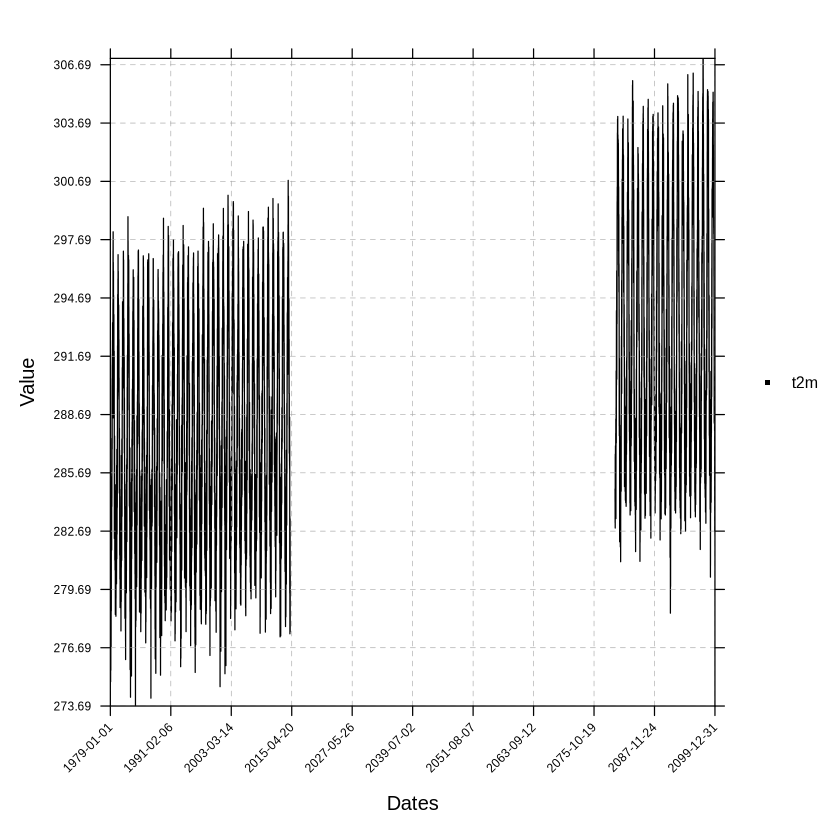

In [24]:
temporalPlot(t2m)

In [25]:
scalingDeltaMapping <- function(grid, base, ref) {
  ### remove the seasonal trend
  grid_detrended <- scaleGrid(grid, 
                              base = grid, 
                              ref = base, 
                              type = "center", 
                              spatial.frame = "gridbox", 
                              time.frame = "daily")  
  
  ### bias correct the mean and variance
  grid_detrended_corrected <- scaleGrid(grid_detrended, 
                                        base = base, 
                                        ref = ref, 
                                        type = "standardize", 
                                        spatial.frame = "gridbox", 
                                        time.frame = "daily")    
  
  ### add the seasonal trend
  grid_corrected <- scaleGrid(grid_detrended_corrected, 
                              base = base, 
                              ref = grid, 
                              type = "center", 
                              spatial.frame = "gridbox", 
                              time.frame = "daily")    
  
  ### return 
  return(grid_corrected)
}

standardize <- function(grid, base){
  scaleGrid(grid, 
            base = base,
            ref = NULL,
            type = "standardize"
  ) 
}

In [26]:
raw.x.full <- makeMultiGrid(t2m, hurs, sfcwind)

In [27]:
raw.x <- subsetGrid(raw.x.full, years = 2080:2099)
# Standardize predictors
harmonize.base <- subsetGrid(raw.x.full, years = 1979:2014)

In [28]:
x.harm <- scalingDeltaMapping(raw.x, base = harmonize.base, ref = xTrain)

[2026-04-28 17:52:18.940233] - Scaling by julian days ...

[2026-04-28 17:52:21.660074] - Done

[2026-04-28 17:52:22.567482] - Scaling by julian days ...

[2026-04-28 17:52:27.577298] - Done

[2026-04-28 17:52:28.311535] - Scaling by julian days ...

[2026-04-28 17:52:31.137472] - Done



In [29]:
xn <- standardize(x.harm, base = xTrain)

[2026-04-28 17:52:31.146386] - Scaling ...

[2026-04-28 17:52:31.575047] - Done



---
<a id='phase4-anchor'></a>

## Phase 4: Downscaling 

### High-Resolution Fire Weather Projections

This phase generates the final downscaled projections. 

First, we prepare the preprocessed GCM data to feed the DL model.

In [30]:
xyT_test <- prepareNewData.keras(xn, xyT)

<div style="border-left: 6px solid #3498db; background-color: #eef7ff; padding: 15px; border-radius: 8px;">

<h3 style="margin-top: 0; color: #21618c;">🧹 Memory Management Recommendation</h3>

<p>
To ensure stable execution and avoid unnecessary resource consumption, it is strongly recommended to <b>release unused memory</b> before continuing with the next steps of the notebook.
</p>

<p>
This is particularly important after training, loading large datasets, or handling high-dimensional tensors.
</p>

<ul>
  <li>Delete unused variables and model instances</li>
</ul>

<p style="margin-bottom: 0;">
<b>Efficient memory management helps maintain performance and prevents execution failures.</b>
</p>

</div>

In [31]:
rm(xn, xyT, harmonize.base, xTrain, xTrain_stand, raw.x, raw.x.full)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2973065,158.8,6474891,345.8,6474891,345.8
Vcells,190947591,1456.9,678724402,5178.3,848396780,6472.8


Finally, we can predict using our DL model:

In [32]:
pred <- downscalePredict.keras(xyT_test,
                               model = model,
                               C4R.template = yTrain,
                               clear.session = TRUE)

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned



We apply an ERA5 mask for the predicted data:

In [33]:
mask <- loadGridData("data/ERA5/mask_ERA5Land.nc", var = "mask")

[2026-04-28 17:53:06.443801] Defining geo-location parameters

[2026-04-28 17:53:06.486991] Defining time selection parameters

[2026-04-28 17:53:06.494306] Retrieving data subset ...

[2026-04-28 17:53:06.525247] Done



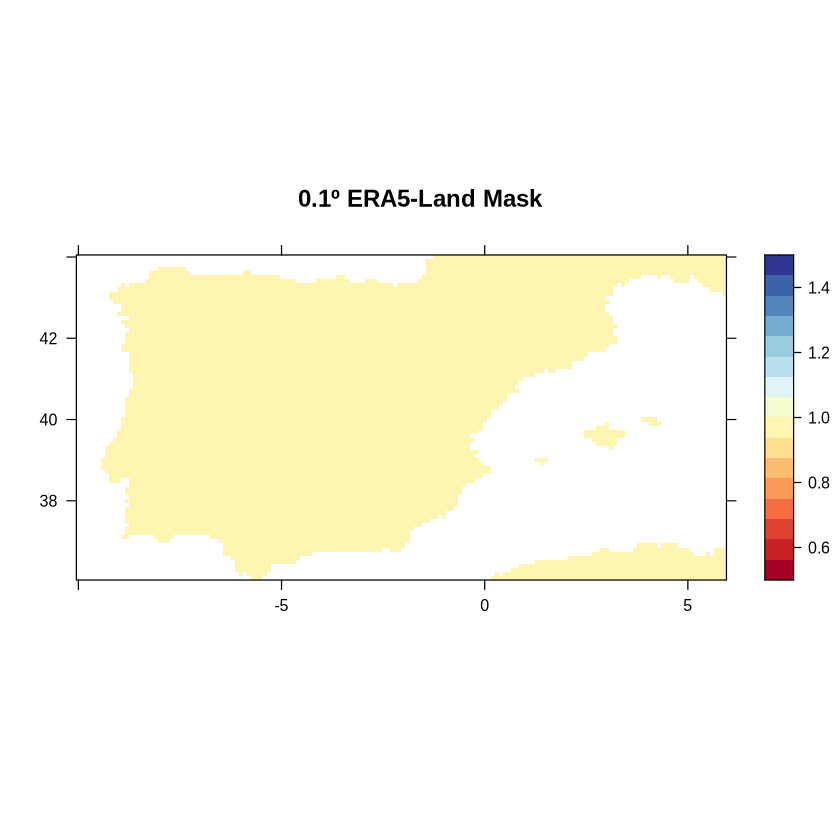

In [34]:
spatialPlot(mask, main = "0.1º ERA5-Land Mask", 
           scales = list(draw = TRUE))

In [35]:
for(i in 1:getShape(pred, "time")){
    pred$Data[i,,] <- pred$Data[i,,]*mask$Data
}

[2026-04-28 17:53:10.049124] - Computing climatology...

[2026-04-28 17:53:11.489442] - Done.



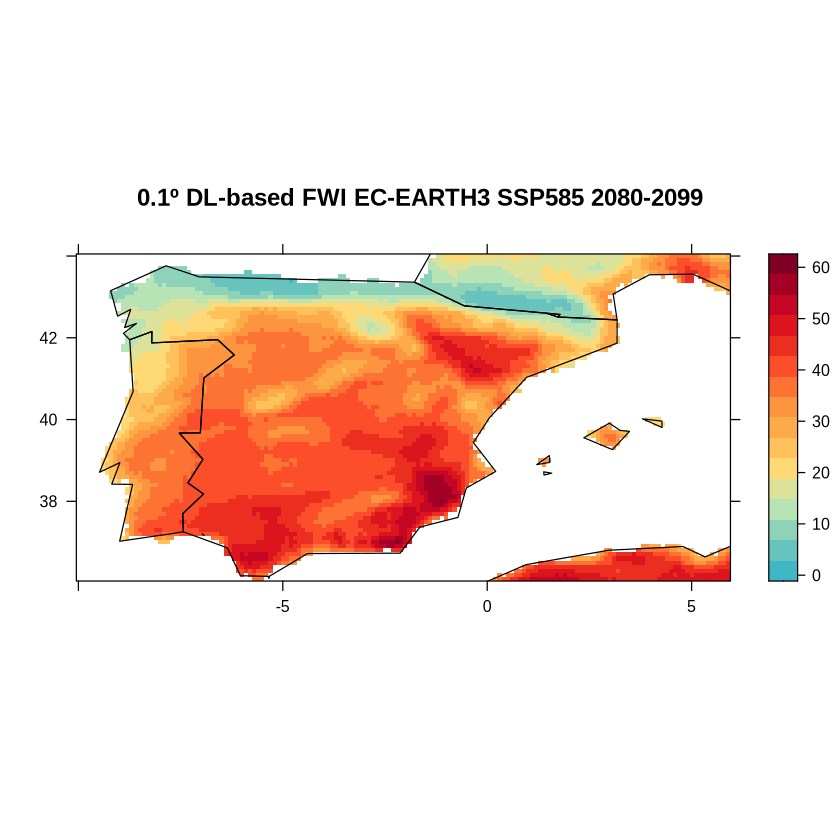

In [36]:
spatialPlot(climatology(pred), backdrop.theme = 'countries', col.regions = fwi.colors,
           main = "0.1º DL-based FWI EC-EARTH3 SSP585 2080-2099", scales = list(draw = TRUE))

✅ **Successfully Downscaled** FWI from 1.5° to 0.1° (~11 km) for EC-EARTH3 model under SSP5-8.5 emission scenario.

---

**Reference:** Mirones et al. (2026). Robust Deep Learning Projections Reveal Intensification and Seasonal Reorganization of Fire Weather over the Iberian Peninsula. *Manuscript submitted to Earth's Future*.